# Sistemas Inteligentes I
## Búsqueda informada: Costo Uniforme, A* y Beam Search

**Autor:** Jairo I. Vélez B.

### Propósito
Estudiar tres estrategias para decidir qué nodo expandir primero usando el costo acumulado y, cuando corresponde, una heurística.

Al finalizar, el estudiante podrá:
- diferenciar búsqueda no informada e informada;
- interpretar $g(n)$, $h(n)$ y $f(n)$;
- implementar Costo Uniforme, A* y Beam Search;
- comparar costo, estados expandidos y calidad de solución;
- analizar el efecto de una heurística.

# 1. Idea central

En BFS y DFS la frontera se organiza sin estimar qué nodo está más cerca del objetivo. En búsqueda informada podemos incorporar información adicional.

- $g(n)$: costo acumulado desde el inicio hasta $n$.
- $h(n)$: estimación del costo desde $n$ hasta el objetivo.
- En A*: $f(n)=g(n)+h(n)$.

**Costo Uniforme:** prioriza menor $g(n)$.  
**A\*:** prioriza menor $g(n)+h(n)$.  
**Beam Search:** conserva solo los mejores $k$ candidatos de cada nivel.

In [132]:

from heapq import heappush, heappop
from itertools import count
import math
import matplotlib.pyplot as plt

print("Entorno listo")

Entorno listo


# 2. Problema base: grafo ponderado

- Estado inicial: `A`
- Objetivo: `G`
- Cada arista tiene un costo.

In [133]:
grafo = {
    "A": {"B": 2, "C": 4},
    "B": {"D": 5, "E": 10},
    "C": {"E": 3, "F": 6},
    "D": {"G": 4},
    "E": {"G": 2},
    "F": {"G": 3},
    "G": {}
}
grafo

{'A': {'B': 2, 'C': 4},
 'B': {'D': 5, 'E': 10},
 'C': {'E': 3, 'F': 6},
 'D': {'G': 4},
 'E': {'G': 2},
 'F': {'G': 3},
 'G': {}}

# 3. Búsqueda de Costo Uniforme (UCS)

Expande el nodo con menor costo acumulado:

$$f(n)=g(n)$$

No usa heurística. La frontera se implementa con una cola de prioridad.

In [134]:
def costo_uniforme(grafo, inicio, objetivo):
    orden = count()
    frontera = []
    heappush(frontera, (0, next(orden), inicio, [inicio]))
    mejor_g = {inicio: 0}
    expandidos = 0

    while frontera:
        g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}

        for vecino, costo in grafo[nodo].items():
            nuevo_g = g + costo
            if nuevo_g < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = nuevo_g
                heappush(frontera, (nuevo_g, next(orden), vecino, camino + [vecino]))
    return None

resultado_ucs = costo_uniforme(grafo, "A", "G")
resultado_ucs

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

## 3.1 UCS paso a paso

In [135]:
def ucs_debug(grafo, inicio, objetivo):
    orden = count(); frontera=[]
    heappush(frontera,(0,next(orden),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(g,n) for g,_,n,_ in frontera])
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        print(f"Expandimos {nodo}: g={g}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(orden),vecino,camino+[vecino]))
        paso += 1

ucs_debug(grafo,"A","G")


Paso 1
Frontera: [(0, 'A')]
Expandimos A: g=0

Paso 2
Frontera: [(2, 'B'), (4, 'C')]
Expandimos B: g=2

Paso 3
Frontera: [(4, 'C'), (7, 'D'), (12, 'E')]
Expandimos C: g=4

Paso 4
Frontera: [(7, 'D'), (10, 'F'), (7, 'E'), (12, 'E')]
Expandimos D: g=7

Paso 5
Frontera: [(7, 'E'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos E: g=7

Paso 6
Frontera: [(9, 'G'), (10, 'F'), (12, 'E'), (11, 'G')]
Expandimos G: g=9


(['A', 'C', 'E', 'G'], 9)

# 4. Heurística

Hasta ahora, **Costo Uniforme** solo utiliza información sobre el costo ya recorrido:

\[
g(n)
\]

Para orientar la búsqueda hacia el objetivo podemos incorporar una estimación:

\[
h(n)
\]

donde \(h(n)\) representa una **estimación del costo mínimo restante** desde el nodo \(n\) hasta el objetivo.

## ¿De dónde salen estos valores?

En un problema real, una heurística debe derivarse de alguna propiedad del dominio: distancia geométrica, cantidad de elementos fuera de lugar, una relajación del problema, conocimiento experto, etc.

En este grafo pequeño conocemos toda la estructura, por lo que podemos calcular el costo real mínimo desde cada nodo hasta `G`. Lo usaremos únicamente con fines didácticos para evaluar la calidad de una heurística.

In [136]:
# Costo real mínimo desde cada nodo hasta G.
# En un problema real normalmente NO conoceríamos estos valores de antemano.

costo_real_hasta_G = {
    "A": 9,
    "B": 9,
    "C": 5,
    "D": 4,
    "E": 2,
    "F": 3,
    "G": 0,
}

costo_real_hasta_G

{'A': 9, 'B': 9, 'C': 5, 'D': 4, 'E': 2, 'F': 3, 'G': 0}

## 4.1 Costo real vs. estimación heurística

Denotaremos el costo real mínimo restante como:

$$
h^*(n)
$$

La heurística $$h(n)$$ intenta aproximarlo:

$$
h(n)\approx h^*(n)
$$

Una heurística es **admisible** cuando nunca sobreestima el costo real:

$$
\boxed{h(n)\leq h^*(n)}
$$

Para este ejemplo utilizaremos una heurística **admisible pero imperfecta**:

| Nodo | $$h(n)$$ | $$h^*(n)$$ |
|---|---:|---:|
| A | 7 | 9 |
| B | 6 | 9 |
| C | 4 | 5 |
| D | 3 | 4 |
| E | 2 | 2 |
| F | 2 | 3 |
| G | 0 | 0 |

La heurística no conoce exactamente la solución: solo proporciona una estimación razonable.

In [137]:
heuristica = {
    "A": 7,
    "B": 6,
    "C": 4,
    "D": 3,
    "E": 2,
    "F": 2,
    "G": 0,
}

heuristica

{'A': 7, 'B': 6, 'C': 4, 'D': 3, 'E': 2, 'F': 2, 'G': 0}

In [138]:
# Verificación de admisibilidad
comparacion_heuristica = {
    nodo: {
        "h(n)": heuristica[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "admisible": heuristica[nodo] <= costo_real_hasta_G[nodo],
    }
    for nodo in heuristica
}

comparacion_heuristica

{'A': {'h(n)': 7, 'h*(n)': 9, 'admisible': True},
 'B': {'h(n)': 6, 'h*(n)': 9, 'admisible': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'admisible': True},
 'D': {'h(n)': 3, 'h*(n)': 4, 'admisible': True},
 'E': {'h(n)': 2, 'h*(n)': 2, 'admisible': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'admisible': True},
 'G': {'h(n)': 0, 'h*(n)': 0, 'admisible': True}}

### Idea clave

> **La heurística no tiene que acertar exactamente. Tiene que estimar.**

Una heurística demasiado débil puede aportar poca información.  
Una heurística que sobreestima puede orientar de manera agresiva la búsqueda, pero puede perder garantías de optimalidad.

# 5. A*

A* combina costo acumulado y estimación:

$$\boxed{f(n)=g(n)+h(n)}$$

Se expande primero el nodo con menor $f(n)$.

In [139]:
def a_estrella(grafo, heuristica, inicio, objetivo):
    tie = count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; expandidos=0

    while frontera:
        f,g,_,nodo,camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}

        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar = a_estrella(grafo,heuristica,"A","G")
resultado_astar

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

## 5.1 A* paso a paso

In [140]:
def astar_debug(grafo, heuristica, inicio, objetivo):
    tie=count(); frontera=[]
    heappush(frontera,(heuristica[inicio],0,next(tie),inicio,[inicio]))
    mejor_g={inicio:0}; paso=1
    while frontera:
        print(f"\nPaso {paso}")
        print("Frontera:", [(n,g,f) for f,g,_,n,_ in frontera])
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        print(f"Expandimos {nodo}: g={g}, h={heuristica[nodo]}, f={f}")
        if nodo==objetivo: return camino,g
        for vecino,costo in grafo[nodo].items():
            ng=g+costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+heuristica[vecino]
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
        paso += 1

astar_debug(grafo,heuristica,"A","G")


Paso 1
Frontera: [('A', 0, 7)]
Expandimos A: g=0, h=7, f=7

Paso 2
Frontera: [('B', 2, 8), ('C', 4, 8)]
Expandimos B: g=2, h=6, f=8

Paso 3
Frontera: [('C', 4, 8), ('D', 7, 10), ('E', 12, 14)]
Expandimos C: g=4, h=4, f=8

Paso 4
Frontera: [('E', 7, 9), ('F', 10, 12), ('D', 7, 10), ('E', 12, 14)]
Expandimos E: g=7, h=2, f=9

Paso 5
Frontera: [('G', 9, 9), ('D', 7, 10), ('E', 12, 14), ('F', 10, 12)]
Expandimos G: g=9, h=0, f=9


(['A', 'C', 'E', 'G'], 9)

## 5.2 Tres casos para entender el papel de la heurística

Antes de comparar los algoritmos, observemos qué ocurre con A* bajo tres configuraciones distintas de \(h(n)\).

### Caso 1 — Sin heurística

Si:

$$
h(n)=0 \quad \forall n
$$

entonces:

$$
f(n)=g(n)
$$

y A* se comporta como **Costo Uniforme**.

In [141]:
heuristica_cero = {nodo: 0 for nodo in grafo}

resultado_astar_h0 = a_estrella(
    grafo,
    heuristica_cero,
    "A",
    "G"
)

resultado_astar_h0

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6}

### Caso 2 — Heurística admisible

Usamos la heurística definida anteriormente:

$$
h(n)\leq h^*(n)
$$

La búsqueda dispone de información para orientar la expansión sin sobreestimar el costo real restante.

In [142]:
resultado_astar_admisible = a_estrella(
    grafo,
    heuristica,
    "A",
    "G"
)

resultado_astar_admisible

{'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}

### Caso 3 — Heurística que sobreestima

Ahora construiremos deliberadamente una heurística **no admisible**.

Algunos valores cumplen:

$$
h(n)>h^*(n)
$$

Esto no significa que A* necesariamente encuentre una mala solución, pero ya no podemos asumir las mismas garantías de optimalidad.

In [143]:
heuristica_sobreestima = {
    "A": 12,  # costo real = 9
    "B": 10,  # costo real = 9
    "C": 4,
    "D": 3,
    "E": 7,   # costo real = 2
    "F": 2,
    "G": 0,
}

comparacion_sobreestimacion = {
    nodo: {
        "h(n)": heuristica_sobreestima[nodo],
        "h*(n)": costo_real_hasta_G[nodo],
        "sobreestima": heuristica_sobreestima[nodo] > costo_real_hasta_G[nodo],
    }
    for nodo in heuristica_sobreestima
}

comparacion_sobreestimacion

{'A': {'h(n)': 12, 'h*(n)': 9, 'sobreestima': True},
 'B': {'h(n)': 10, 'h*(n)': 9, 'sobreestima': True},
 'C': {'h(n)': 4, 'h*(n)': 5, 'sobreestima': False},
 'D': {'h(n)': 3, 'h*(n)': 4, 'sobreestima': False},
 'E': {'h(n)': 7, 'h*(n)': 2, 'sobreestima': True},
 'F': {'h(n)': 2, 'h*(n)': 3, 'sobreestima': False},
 'G': {'h(n)': 0, 'h*(n)': 0, 'sobreestima': False}}

In [144]:
resultado_astar_sobreestima = a_estrella(
    grafo,
    heuristica_sobreestima,
    "A",
    "G"
)

resultado_astar_sobreestima

{'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}

### Comparación de los tres casos

Compare:

- camino encontrado,
- costo total,
- nodos expandidos.

La idea importante es que una heurística no admisible **no necesariamente falla siempre**; simplemente deja de cumplir las condiciones que permiten garantizar la optimalidad de A*.

In [145]:
comparacion_tres_heuristicas = {
    "h(n)=0": resultado_astar_h0,
    "Admisible": resultado_astar_admisible,
    "Sobreestima": resultado_astar_sobreestima,
}

comparacion_tres_heuristicas

{'h(n)=0': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 6},
 'Admisible': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5},
 'Sobreestima': {'camino': ['A', 'B', 'D', 'G'], 'costo': 11, 'expandidos': 5}}

# 6. Comparación inicial

**Pregunta clave:** ¿qué ocurre si $h(n)=0$ para todos los nodos?  
A* se comporta como Costo Uniforme.

In [146]:
{
    "Costo Uniforme": resultado_ucs,
    "A*": resultado_astar
}

{'Costo Uniforme': {'camino': ['A', 'C', 'E', 'G'],
  'costo': 9,
  'expandidos': 6},
 'A*': {'camino': ['A', 'C', 'E', 'G'], 'costo': 9, 'expandidos': 5}}

# 7. Caso aplicado: cuadrícula

Ahora trabajaremos con un mapa:

- `0`: celda libre
- `1`: obstáculo
- acciones: arriba, abajo, izquierda y derecha
- costo de cada movimiento: 1

Para A* usaremos distancia Manhattan:

$$h(n)=|x_n-x_g|+|y_n-y_g|$$

In [147]:
mapa = [
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0],
    [0,0,0,1,0,1,0],
    [1,1,0,1,0,0,0],
    [0,0,0,0,1,1,0],
    [0,1,1,0,0,0,0],
    [0,0,0,0,1,0,0],
]
INICIO=(0,0); OBJETIVO=(6,6)
MOVIMIENTOS=[(1,0),(-1,0),(0,1),(0,-1)]

def sucesores_mapa(mapa,pos):
    filas=len(mapa); cols=len(mapa[0]); f,c=pos; out=[]
    for df,dc in MOVIMIENTOS:
        nf,nc=f+df,c+dc
        if 0<=nf<filas and 0<=nc<cols and mapa[nf][nc]==0:
            out.append((nf,nc))
    return out

def manhattan(a,b):
    return abs(a[0]-b[0])+abs(a[1]-b[1])

## 7.1 Costo Uniforme en la cuadrícula

In [148]:
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa,INICIO,OBJETIVO)
resultado_ucs_mapa

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 35}

## 7.2 A* en la cuadrícula

In [149]:
def astar_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(manhattan(inicio,objetivo),0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        f,g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                nf=ng+manhattan(vecino,objetivo)
                heappush(frontera,(nf,ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_astar_mapa=astar_mapa(mapa,INICIO,OBJETIVO)
resultado_astar_mapa

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 29}

## 7.3 Visualización

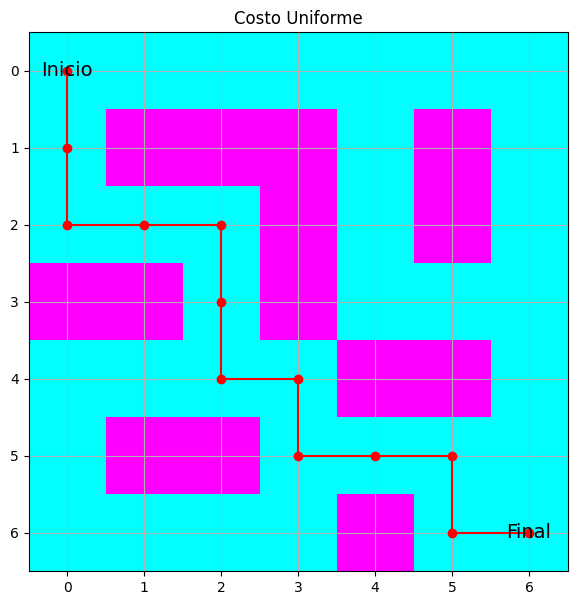

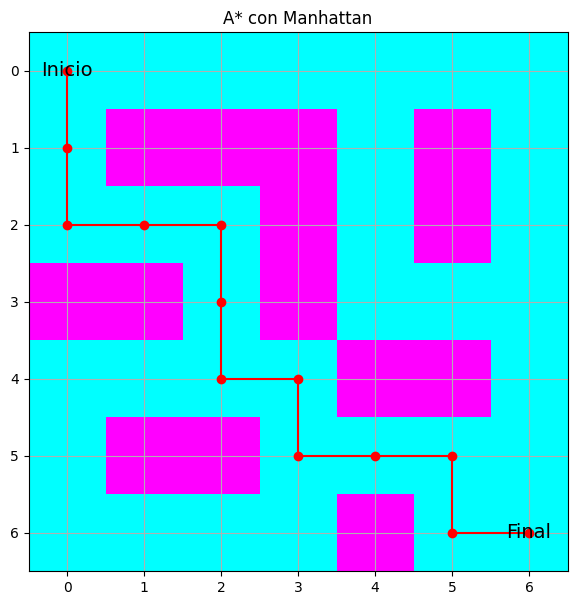

In [150]:
def mostrar_mapa(mapa, camino=None, inicio=None, objetivo=None, titulo="Mapa"):
    fig,ax=plt.subplots(figsize=(7,7))
    ax.imshow(mapa,cmap='cool')
    if camino:
        xs=[c for f,c in camino]; ys=[f for f,c in camino]
        ax.plot(xs,ys,c='red',marker="o")
    if inicio: ax.text(inicio[1],inicio[0],"Inicio",ha="center",va="center",fontsize=14)
    if objetivo: ax.text(objetivo[1],objetivo[0],"Final",ha="center",va="center",fontsize=14)
    ax.set_xticks(range(len(mapa[0]))); ax.set_yticks(range(len(mapa)))
    ax.set_title(titulo); ax.grid(True); plt.show()

mostrar_mapa(mapa,resultado_ucs_mapa["camino"],INICIO,OBJETIVO,"Costo Uniforme")
mostrar_mapa(mapa,resultado_astar_mapa["camino"],INICIO,OBJETIVO,"A* con Manhattan")

## 7.4 Comparación experimental

In [151]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]}
}

{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29}}

# 8. Beam Search

Beam Search limita deliberadamente la cantidad de estados conservados en cada nivel.

$$k=\text{beam width}$$

Si $k=2$, solo se mantienen los dos estados más prometedores del nivel.

Ventaja: reduce memoria y exploración.  
Riesgo: puede descartar un estado que conduzca a la mejor solución. Por eso no garantiza optimalidad y puede fallar aunque exista solución.

In [152]:
def beam_search_mapa(mapa,inicio,objetivo,beam_width=2):
    haz=[(inicio,[inicio])]
    visitados={inicio}
    expandidos=0

    while haz:
        candidatos=[]
        for nodo,camino in haz:
            expandidos += 1
            if nodo==objetivo:
                return {"camino":camino,"costo":len(camino)-1,"expandidos":expandidos,"beam_width":beam_width}
            for vecino in sucesores_mapa(mapa,nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino,camino+[vecino]))

        candidatos.sort(key=lambda x: manhattan(x[0],objetivo))
        haz=candidatos[:beam_width]
    return None

resultado_beam=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=3)
resultado_beam

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (5, 3),
  (5, 4),
  (5, 5),
  (6, 5),
  (6, 6)],
 'costo': 12,
 'expandidos': 31,
 'beam_width': 3}

## 8.1 Experimentar con diferentes anchos de haz

In [153]:
resultados_beam={}
for k in [1,2,3,5,10]:
    resultados_beam[k]=beam_search_mapa(mapa,INICIO,OBJETIVO,beam_width=k)
resultados_beam

{1: None,
 2: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 24,
  'beam_width': 2},
 3: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 31,
  'beam_width': 3},
 5: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 5},
 10: {'camino': [(0, 0),
   (1, 0),
   (2, 0),
   (2, 1),
   (2, 2),
   (3, 2),
   (4, 2),
   (4, 3),
   (5, 3),
   (5, 4),
   (5, 5),
   (6, 5),
   (6, 6)],
  'costo': 12,
  'expandidos': 35,
  'beam_width': 10}}

# 9. Comparación global

In [154]:
{
    "Costo Uniforme": {"costo":resultado_ucs_mapa["costo"],"expandidos":resultado_ucs_mapa["expandidos"]},
    "A*": {"costo":resultado_astar_mapa["costo"],"expandidos":resultado_astar_mapa["expandidos"]},
    "Beam Search k=3": None if resultado_beam is None else {"costo":resultado_beam["costo"],"expandidos":resultado_beam["expandidos"]}
}

{'Costo Uniforme': {'costo': 12, 'expandidos': 35},
 'A*': {'costo': 12, 'expandidos': 29},
 'Beam Search k=3': {'costo': 12, 'expandidos': 31}}

## 9.1 Resumen conceptual

| Algoritmo | Prioriza | Heurística | ¿Óptimo? | Memoria |
|---|---|---:|---|---|
| Costo Uniforme | menor $g(n)$ | No | Sí, con costos no negativos | Puede ser alta |
| A* | menor $g(n)+h(n)$ | Sí | Sí, bajo condiciones adecuadas | Puede ser alta |
| Beam Search | mejores $k$ candidatos | Sí | No garantizado | Controlada |

**Idea clave:**
- Costo Uniforme sabe cuánto ha costado llegar.
- A* sabe cuánto ha costado llegar y estima cuánto falta.
- Beam Search sacrifica exhaustividad para controlar el tamaño de la búsqueda.

# 10. Interpretación de la calidad de una heurística

Ya observamos tres escenarios:

- **Heurística nula:** no aporta información y A* se reduce a Costo Uniforme.
- **Heurística admisible:** orienta la búsqueda sin sobreestimar el costo real restante.
- **Heurística no admisible:** puede priorizar de forma agresiva ciertos caminos, pero pierde la garantía de optimalidad.

### Para discutir

1. ¿Una heurística con valores más grandes es necesariamente mejor?
2. ¿Qué diferencia existe entre una heurística **informativa** y una heurística que simplemente sobreestima?
3. ¿Por qué no podemos usar \(h^*(n)\) directamente como heurística en un problema real?
4. ¿Qué ocurriría si calcular \(h(n)\) fuera casi tan costoso como resolver el problema?
5. ¿Qué propiedades del dominio podrían utilizarse para construir una buena heurística?

# 11. Reto: A* para el 8-puzzle

Compare tres estrategias sobre el mismo problema:

1. BFS
2. A* con fichas fuera de lugar
3. A* con distancia Manhattan

Mida:
- longitud de la solución;
- estados expandidos;
- tiempo de ejecución.

Heurísticas sugeridas:

$$h_1(n)=\text{número de fichas fuera de lugar}$$

$$h_2(n)=\sum_i (|x_i-x_i^*|+|y_i-y_i^*|)$$

In [155]:
def obtener_vecinos(estado):
    """
    Genera los estados vecinos válidos para el 8-puzzle.
    
    Argumentos:
    estado: Tupla de tuplas representando el tablero 3x3.
    
    Retorna:
    Una lista de estados (tuplas de tuplas) resultantes de un movimiento válido.
    """
    vecinos = []
    
    # 1. Encontrar la posición (fila, columna) del espacio vacío (0)
    fila_vacia, col_vacia = -1, -1
    for i in range(3):
        for j in range(3):
            if estado[i][j] == 0:
                fila_vacia, col_vacia = i, j
                break
        if fila_vacia != -1:
            break
            
    # 2. Definir los posibles movimientos de la casilla vacía: 
    # (delta_fila, delta_columna) -> Arriba, Abajo, Izquierda, Derecha
    movimientos = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    for df, dc in movimientos:
        nueva_fila = fila_vacia + df
        nueva_col = col_vacia + dc
        
        # 3. Verificar que el movimiento esté dentro de los límites del tablero
        if 0 <= nueva_fila < 3 and 0 <= nueva_col < 3:
            # Convertir la tupla de tuplas a lista de listas para poder modificar los valores
            estado_lista = [list(fila) for fila in estado]
            
            # Realizar el intercambio (swap) entre el 0 y la ficha adyacente
            ficha_a_mover = estado_lista[nueva_fila][nueva_col]
            estado_lista[fila_vacia][col_vacia] = ficha_a_mover
            estado_lista[nueva_fila][nueva_col] = 0
            
            # Convertir nuevamente a tupla de tuplas (inmutable/hashable)
            nuevo_estado = tuple(tuple(fila) for fila in estado_lista)
            vecinos.append(nuevo_estado)
            
    return vecinos

In [156]:
import heapq

def astar_8_puzzle(estado_inicial, estado_objetivo, heuristica):
    """
    Resuelve el 8-puzzle utilizando el algoritmo de búsqueda A*.
    
    Argumentos:
    estado_inicial: El estado inicial del tablero (debe ser inmutable, ej. tupla de tuplas).
    estado_objetivo: El estado objetivo al que se quiere llegar.
    heuristica: Función que calcula la distancia heurística entre un estado y el objetivo.
    
    Retorna:
    Un diccionario con el camino encontrado y la cantidad de nodos explorados, o None si no hay solución.
    """
    # Frontera es una cola de prioridad. Almacena tuplas: (f_score, id_orden, estado, camino)
    # id_orden se usa para desempatar si dos estados tienen el mismo f_score
    frontera = []
    id_orden = 0
    
    # h(n) inicial
    h_inicial = heuristica(estado_inicial, estado_objetivo)
    
    # g(n) inicial es 0. Por lo tanto f(n) = h(n)
    heapq.heappush(frontera, (h_inicial, id_orden, estado_inicial, [estado_inicial]))
    
    # Conjunto para guardar los estados ya explorados y evitar ciclos (requiere que los estados sean hashables)
    explorados = set()
    
    # Diccionario para mantener el costo real (g_score) más bajo desde el inicio hasta cada estado
    g_scores = {estado_inicial: 0}

    while frontera:
        # Extraemos el estado con el menor f_score
        f_actual, _, estado_actual, camino = heapq.heappop(frontera)
        
        # Si llegamos al objetivo, retornamos el resultado
        if estado_actual == estado_objetivo:
            return {
                "camino": camino,
                "explorados": len(explorados)
            }
            
        explorados.add(estado_actual)
        
        # Generar los sucesores/vecinos del estado actual
        # NOTA: Asegúrate de tener definida esta función que retorna los movimientos válidos
        vecinos = obtener_vecinos(estado_actual) 
        
        for vecino in vecinos:
            # En el 8-puzzle, cada movimiento tiene un costo de 1
            g_tentativo = g_scores[estado_actual] + 1
            
            # Si el vecino ya fue explorado y encontramos un camino peor o igual, lo ignoramos
            if vecino in explorados and g_tentativo >= g_scores.get(vecino, float('inf')):
                continue
                
            # Si es un estado nuevo o encontramos un camino más corto hacia él
            if g_tentativo < g_scores.get(vecino, float('inf')):
                g_scores[vecino] = g_tentativo
                f_vecino = g_tentativo + heuristica(vecino, estado_objetivo)
                
                id_orden += 1
                nuevo_camino = camino + [vecino]
                
                # Añadimos el vecino a la frontera
                heapq.heappush(frontera, (f_vecino, id_orden, vecino, nuevo_camino))
                
    return None # Retorna None si la frontera se vacía y no se encontró solución

In [157]:
# ------ Demostracion del reto: A* para el 8-puzzle ------

def h_manhattan_8_puzzle(estado, objetivo):
    """Distancia Manhattan entre un estado y el objetivo."""
    pos_objetivo = {objetivo[i][j]: (i, j) for i in range(3) for j in range(3)}
    total = 0
    for i in range(3):
        for j in range(3):
            ficha = estado[i][j]
            if ficha != 0:
                oi, oj = pos_objetivo[ficha]
                total += abs(i - oi) + abs(j - oj)
    return total

inicio_reto = (
    (1, 0, 3),
    (4, 2, 5),
    (7, 8, 6),
)

objetivo_reto = (
    (1, 2, 3),
    (4, 5, 6),
    (7, 8, 0),
)

solucion_reto = astar_8_puzzle(inicio_reto, objetivo_reto, h_manhattan_8_puzzle)

if solucion_reto is None:
    print("No se encontro solucion.")
else:
    camino = solucion_reto["camino"]
    print("Camino encontrado: {} movimientos, {} estados explorados\n".format(
        len(camino) - 1, solucion_reto["explorados"]))
    for paso, estado in enumerate(camino):
        print("Paso {}:".format(paso))
        for fila in estado:
            print(" ".join(str(x) for x in fila))
        print()


Camino encontrado: 3 movimientos, 3 estados explorados

Paso 0:
1 0 3
4 2 5
7 8 6

Paso 1:
1 2 3
4 0 5
7 8 6

Paso 2:
1 2 3
4 5 0
7 8 6

Paso 3:
1 2 3
4 5 6
7 8 0



# 12. Preguntas de cierre

1. ¿Cuál es la diferencia entre $g(n)$ y $h(n)$?
    R// La diferencia entre g(n) y h(n) está en que el primero me da el costo acumulado desde el inicio hasta $n$, mientras h(n) estima el costo desde n hasta el objetivo, el final.
2. ¿Por qué Costo Uniforme no es una búsqueda heurística?
    R// Costo uniforme no es una heurística porque en este se utiliza únicamente g(n) y no se utiliza h(n); no incorpora la estimación del costo restante.
3. ¿Por qué A* puede expandir menos nodos que Costo Uniforme?
    R// Porque tiene en cuenta el pasado, o sea g(n), y la estimación de h(n) para buscar el menor entre la suma de esos. Esto pasa cuando la heurística es admisible y buena.
4. ¿Qué pierde Beam Search al limitar la frontera?
    R// Puede causar que se elimine un estado que conduzca a una mejor solución.
5. ¿Qué algoritmo elegiría si necesita garantizar la solución de menor costo?
   R// Si no hay heurística útil, Costo Uniforme garantiza costo mínimo; con heurística admisible, A* también lo hace y suele ser más eficiente.
6. ¿Cuál elegiría si dispone de memoria muy limitada?
   R// Beam Search, ya que elimina estados, lo que garantiza una menor cantidad de cálculos.
7.  ¿Qué papel cumple la calidad de la heurística?
    R// Garantiza que el proceso de análisis dure menos tiempo, ya que se busca una solución lo más rápido, pero no garantiza que sea la mejor; una heurística buena reduce nodos explorados y acelera la búsqueda.

# 13. Taller posterior

### Parte 1 — Cuadrícula
Construya un mapa de al menos `12 × 12` y ejecute:
- Costo Uniforme;
- A*;
- Beam Search con `k = 1, 2, 4, 8`.

Compare costo de solución, estados expandidos y capacidad para encontrar solución.

### Parte 2 — Heurísticas
Implemente dos heurísticas distintas para A* y analice cuál orienta mejor la búsqueda.

### Parte 3 — 8-puzzle
Implemente A* con fichas fuera de lugar y distancia Manhattan y compare con BFS.

### Pregunta final
**¿Puede una búsqueda más rápida producir una solución peor? Explique usando sus experimentos.**
R// Sí, una búsqueda más rápida puede producir una solución peor, aunque no siempre ocurre. En los experimentos, Beam Search exploró menos estados y utilizó menos recursos, pero no garantiza encontrar la solución óptima e incluso puede no encontrar ninguna. Esto sucede porque limita la frontera y descarta algunos caminos prometedores. Por otro lado, A* con una heurística admisible encontró soluciones del mismo costo que Costo Uniforme, pero expandiendo menos estados. Por tanto, la rapidez puede lograrse sacrificando optimalidad, especialmente en métodos como Beam Search.

### Uso de IA generativa
Si utiliza IA generativa, indique herramienta, propósito y partes de la actividad en las que fue utilizada. Debe poder explicar y defender completamente el trabajo entregado.
 Se utilizo open code para encontar las heuristicas del puntos 2 y una explicacion sensilla de como impplementar las ademas de ayudar en la ortografia de las respuesta del apartado 12 del notebook tambien con el se creo la tabal de comparacion para poder ver las comparaciones 


In [158]:
# ---------- Mapa 12x12 (0 = libre, 1 = obstaculo) ----------
mapa_12 = [
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0],
]
INICIO_12 = (0, 0)
OBJETIVO_12 = (11, 11)
MOVIMIENTOS = [(1, 0), (-1, 0), (0, 1), (0, -1)]

# ---------- Utilidades ----------
def sucesores_mapa(mapa, pos):
    filas, cols = len(mapa), len(mapa[0])
    f, c = pos
    out = []
    for df, dc in MOVIMIENTOS:
        nf, nc = f + df, c + dc
        if 0 <= nf < filas and 0 <= nc < cols and mapa[nf][nc] == 0:
            out.append((nf, nc))
    return out

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

In [159]:
# ---------- Costo Uniforme ----------
def ucs_mapa(mapa,inicio,objetivo):
    tie=count(); frontera=[(0,next(tie),inicio,[inicio])]
    mejor_g={inicio:0}; expandidos=0
    while frontera:
        g,_,nodo,camino=heappop(frontera)
        if g != mejor_g.get(nodo): continue
        expandidos += 1
        if nodo==objetivo:
            return {"camino":camino,"costo":g,"expandidos":expandidos}
        for vecino in sucesores_mapa(mapa,nodo):
            ng=g+1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino]=ng
                heappush(frontera,(ng,next(tie),vecino,camino+[vecino]))
    return None

resultado_ucs_mapa=ucs_mapa(mapa_12,INICIO_12,OBJETIVO_12)
resultado_ucs_mapa

{'camino': [(0, 0),
  (0, 1),
  (0, 2),
  (1, 2),
  (2, 2),
  (2, 3),
  (2, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (5, 5),
  (6, 5),
  (6, 6),
  (7, 6),
  (8, 6),
  (9, 6),
  (10, 6),
  (10, 7),
  (10, 8),
  (10, 9),
  (10, 10),
  (11, 10),
  (11, 11)],
 'costo': 22,
 'expandidos': 88}

In [160]:
#---------- A* ----------
def astar_mapa(mapa, inicio, objetivo):
    tie = count()
    frontera = [(manhattan(inicio, objetivo), 0, next(tie), inicio, [inicio])]
    mejor_g = {inicio: 0}
    expandidos = 0
    while frontera:
        f, g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}
        for vecino in sucesores_mapa(mapa, nodo):
            ng = g + 1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                nf = ng + manhattan(vecino, objetivo)
                heappush(frontera, (nf, ng, next(tie), vecino, camino + [vecino]))
    return None
resultado_astar_mapa=astar_mapa(mapa_12,INICIO_12,OBJETIVO_12)
resultado_astar_mapa

{'camino': [(0, 0),
  (0, 1),
  (0, 2),
  (1, 2),
  (2, 2),
  (2, 3),
  (2, 4),
  (3, 4),
  (4, 4),
  (4, 5),
  (5, 5),
  (6, 5),
  (6, 6),
  (7, 6),
  (8, 6),
  (9, 6),
  (10, 6),
  (10, 7),
  (10, 8),
  (10, 9),
  (10, 10),
  (11, 10),
  (11, 11)],
 'costo': 22,
 'expandidos': 38}

In [161]:
# ---------- Beam Search ----------
def beam_search_mapa(mapa, inicio, objetivo, beam_width):
    haz = [(inicio, [inicio])]
    visitados = {inicio}
    expandidos = 0
    while haz:
        candidatos = []
        for nodo, camino in haz:
            expandidos += 1
            if nodo == objetivo:
                return {"camino": camino, "costo": len(camino) - 1,
                        "expandidos": expandidos, "beam_width": beam_width}
            for vecino in sucesores_mapa(mapa, nodo):
                if vecino not in visitados:
                    visitados.add(vecino)
                    candidatos.append((vecino, camino + [vecino]))
        candidatos.sort(key=lambda x: manhattan(x[0], objetivo))
        haz = candidatos[:beam_width]
    return None
resultados_beam = {k: beam_search_mapa(mapa_12, INICIO_12, OBJETIVO_12, beam_width=k)
                   for k in [1, 2, 4, 8]}

In [162]:
# Tabla comparativa de resultados
print(f"{'Algoritmo':<18}{'Costo':>7}{'Expandidos':>12}{'Solucion':>9}")
print('-' * 46)
for nombre, r in [("Costo Uniforme", resultado_ucs_mapa), ("A*", resultado_astar_mapa)]:
    print(f"{nombre:<18}{r['costo']:>7}{r['expandidos']:>12}{('Si' if r else 'No'):>9}")
for k, r in resultados_beam.items():
    costo = str(r['costo']) if r else '-'
    exp = str(r['expandidos']) if r else '-'
    print(f"Beam k = {k:<12}{costo:>7}{exp:>12}{('Si' if r else 'No'):>9}")

Algoritmo           Costo  Expandidos Solucion
----------------------------------------------
Costo Uniforme         22          88       Si
A*                     22          38       Si
Beam k = 1                 -           -       No
Beam k = 2                22          40       Si
Beam k = 4                22          67       Si
Beam k = 8                22          87       Si


Compare costo de solución, estados expandidos y capacidad para encontrar solución.
Como se en la tabal comparativa algunos de plano no lograron encontar solucion pero se puede saber que en eeste caso concretos todos costaron lo mismo pero la cantidad de nodos estendidos varia dependiendo de la tecnica utilizada 

# Parte 2 — Heurísticas
Implemente dos heurísticas distintas para A* y analice cuál orienta mejor la búsqueda.
Opciones de heurísticas

1. Manhattan — h = |x1-x2| + |y1-y2|. Ignora obstáculos; en grids con movimiento de 4 direcciones y sin obstáculos es exacta, por eso en la práctica es la más informativa y admisible de las geométricas. Ventaja: trivial de calcular y consistente. Desventaja: subestima cuando hay obstáculos que obligan a rodearlos.

2. Distancia exacta h* (BFS desde la meta) — Se ejecuta un BFS/Dijkstra inverso desde el objetivo y h(n) = distancia real mínima desde n hasta la meta. Ventaja: es la mejor heurística admisible posible (domina a todas las demás), A* expande el mínimo de nodos (24 vs 38). Desventaja: requiere pre-procesar el mapa; si el mapa cambia, hay que recalcularla.



In [163]:
# ---------- A* genérico (recibe cualquier heurística) ----------
def astar_con_h(mapa, inicio, objetivo, h):
    tie = count()
    frontera = [(h(inicio, objetivo), 0, next(tie), inicio, [inicio])]
    mejor_g = {inicio: 0}
    expandidos = 0
    while frontera:
        f, g, _, nodo, camino = heappop(frontera)
        if g != mejor_g.get(nodo):
            continue
        expandidos += 1
        if nodo == objetivo:
            return {"camino": camino, "costo": g, "expandidos": expandidos}
        for vecino in sucesores_mapa(mapa, nodo):
            ng = g + 1
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                nf = ng + h(vecino, objetivo)
                heappush(frontera, (nf, ng, next(tie), vecino, camino + [vecino]))
    return None

# ---------- Heurística 1: Manhattan ----------
def h_manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# ---------- Heurística 2: distancia exacta h* (BFS desde la meta) ----------
def precomputar_h_exacta(mapa, objetivo):
    dist = {objetivo: 0}
    frontera = [(0, objetivo)]
    while frontera:
        d, nodo = heappop(frontera)
        if d != dist.get(nodo):
            continue
        for vecino in sucesores_mapa(mapa, nodo):
            nd = d + 1
            if nd < dist.get(vecino, math.inf):
                dist[vecino] = nd
                heappush(frontera, (nd, vecino))
    return lambda a, b: dist.get(a, math.inf)

# ---------- Ejecución y comparación ----------
h_exacta = precomputar_h_exacta(mapa_12, OBJETIVO_12)

resultados_heur = {
    "Manhattan": astar_con_h(mapa_12, INICIO_12, OBJETIVO_12, h_manhattan),
    "Exacta h* (BFS)": astar_con_h(mapa_12, INICIO_12, OBJETIVO_12, h_exacta),
}

print(f"{'Heuristica':<18}{'Costo':>7}{'Expandidos':>12}")
print('-' * 37)
for nombre, r in resultados_heur.items():
    print(f"{nombre:<18}{r['costo']:>7}{r['expandidos']:>12}")

Heuristica          Costo  Expandidos
-------------------------------------
Manhattan              22          38
Exacta h* (BFS)        22          24


#### Interpretación de la Parte 2

Ambas heurísticas encuentran la solución óptima (costo 22), pero la calidad de la estimación marca la diferencia:

- **Manhattan** expandió **38** estados: ignora los obstáculos del mapa, por lo que su estimación es menos precisa y el algoritmo explora más nodos antes de decidir.
- **Exacta $h^*$** (calculada con BFS) expandió **24** estados: representa la distancia real hasta el objetivo, es decir, una heurística **dominante y admisible** que entrega más información sin sobreestimar, reduciendo la exploración.

**Conclusión:** entre dos heurísticas admisibles, la que genere valores más cercanos a $h^*(n)$ orienta mejor la búsqueda y expande menos estados.

# Parte 3 — 8-puzzle
Implemente A* con fichas fuera de lugar y distancia Manhattan y compare con BFS.

In [164]:
from collections import deque
from heapq import heappush, heappop
from itertools import count
import math, random, time

OBJETIVO = (1, 2, 3, 4, 5, 6, 7, 8, 0)  # 0 = casilla vacia (abajo a la derecha)

def fila(i): return i // 3
def col(i): return i % 3

def sucesores_8p(estado):
    """Devuelve (estado_resultante, costo) de mover el 0 en las 4 direcciones."""
    i0 = estado.index(0)
    f, c = fila(i0), col(i0)
    movs = []
    for df, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        nf, nc = f + df, c + dc
        if 0 <= nf < 3 and 0 <= nc < 3:
            j = nf * 3 + nc
            lst = list(estado)
            lst[i0], lst[j] = lst[j], lst[i0]
            movs.append((tuple(lst), 1))
    return movs

# ---------- Heuristicas ----------
def h_fichas_fuera(estado):
    return sum(1 for i, t in enumerate(estado) if t != 0 and i != t)

def h_manhattan_8p(estado):
    return sum(abs(fila(i) - t // 3) + abs(col(i) - t % 3)
               for i, t in enumerate(estado) if t != 0)

# ---------- BFS ----------
def bfs_8p(inicio, objetivo):
    frontera = deque([(inicio, [inicio])])
    visitados = {inicio}
    expandidos = 0
    while frontera:
        estado, camino = frontera.popleft()
        expandidos += 1
        if estado == objetivo:
            return {"longitud": len(camino) - 1, "expandidos": expandidos, "camino": camino}
        for vecino, _ in sucesores_8p(estado):
            if vecino not in visitados:
                visitados.add(vecino)
                frontera.append((vecino, camino + [vecino]))
    return None

# ---------- A* generico ----------
def astar_8p(inicio, objetivo, h):
    tie = count()
    frontera = [(h(inicio), 0, next(tie), inicio, [inicio])]
    mejor_g = {inicio: 0}
    expandidos = 0
    while frontera:
        f, g, _, estado, camino = heappop(frontera)
        if g != mejor_g.get(estado):
            continue
        expandidos += 1
        if estado == objetivo:
            return {"longitud": len(camino) - 1, "expandidos": expandidos, "camino": camino}
        for vecino, costo in sucesores_8p(estado):
            ng = g + costo
            if ng < mejor_g.get(vecino, math.inf):
                mejor_g[vecino] = ng
                nf = ng + h(vecino)
                heappush(frontera, (nf, ng, next(tie), vecino, camino + [vecino]))
    return None

# ---------- Estado inicial reproducible (solucion en 20 movimientos) ----------
def generar_inicial(pasos, semilla):
    rng = random.Random(semilla)
    estado = OBJETIVO
    for _ in range(pasos):
        estado = rng.choice(sucesores_8p(estado))[0]
    return estado

inicio = generar_inicial(100, 4)
print("Estado inicial:", inicio, "\n")

# ---------- Comparacion ----------
algoritmos = {
    "BFS":            lambda: bfs_8p(inicio, OBJETIVO),
    "A* fichas fuera":lambda: astar_8p(inicio, OBJETIVO, h_fichas_fuera),
    "A* Manhattan":   lambda: astar_8p(inicio, OBJETIVO, h_manhattan_8p),
}

resultados = {}
for nombre, fn in algoritmos.items():
    t0 = time.perf_counter()
    r = fn()
    resultados[nombre] = (r, time.perf_counter() - t0)

print(f"{'Algoritmo':<18}{'Longitud':>10}{'Expandidos':>12}{'Tiempo (s)':>11}")
print('-' * 51)
for nombre, (r, t) in resultados.items():
    print(f"{nombre:<18}{r['longitud']:>10}{r['expandidos']:>12}{t:>11.2f}")

Estado inicial: (6, 5, 3, 2, 8, 7, 4, 1, 0) 

Algoritmo           Longitud  Expandidos Tiempo (s)
---------------------------------------------------
BFS                       20       45082       0.14
A* fichas fuera           20       53531       0.34
A* Manhattan              20       30862       0.30


Encomparacion con BFS, A* con Fichas fuera es mucho mas debil expandiencio muchos mas estadosque los otros 2 con esgto aumentando aun mas su tiempo de ejecucion apesar de mantener su longitud por otro lado A* Manhattan es mucho mas precisa que la anterior heuristica ya que expande menos estados y reduciendo su costo en tiempo aun que demora un poco mas que BFS pero o conpensa ocupando menos memoria por que genera menos estados


# 14. Conclusiones y transición

- Costo Uniforme prioriza el costo acumulado.
- A* combina costo acumulado y estimación del costo restante.
- Una buena heurística puede reducir la exploración.
- Beam Search reduce el uso de recursos, pero sacrifica garantías.
